# Stock et al. 2008

So the general Structure is

N -> P1, P2, P3 -> Z1, Z2, Z3, Z4 -> higher order mortality

In [1]:
# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import xso

# Import components and create model

In [2]:
from Stocketal2008_comps import (Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum, 
    ConstantExternalNutrient, LinearForcingInput, 
    MonodGrowth_SizeBased, 
    StockGrazingMatrix, Stock_GGE_MatrixGrazing, 
    StockPhytoMortality, StockZooMortality, StockZooMortality_simpleinput)

In [3]:
Stocketal2008 = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton': ZooSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Grazing
    'Grazing': StockGrazingMatrix,
    'GGE': Stock_GGE_MatrixGrazing,

    # Mortality
    'PhytoMortality': StockPhytoMortality,
    'HigherOrderMortality': StockZooMortality,

    # Forcings
    'N0': ConstantExternalNutrient,
})

Stocketal2008_mortsingleval = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton': ZooSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Grazing
    'Grazing': StockGrazingMatrix,
    'GGE': Stock_GGE_MatrixGrazing,

    # Mortality
    'PhytoMortality': StockPhytoMortality,
    'HigherOrderMortality': StockZooMortality_simpleinput,

    # Forcings
    'N0': ConstantExternalNutrient,
})

In [4]:
# number size classes of phytoplankton and zooplankton
P_num = 3
Z_num = 4

# create initial biomass
phyto_init = np.tile(1.5, (P_num))
zoo_init = np.tile(.1, (Z_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = [0.63, 6.3, 63]
zoo_sizes = [6.3, 63, 630, 6300]

# Phytoplankton parameters
phyto_ks = [0.062, 0.45, 3.3]
phyto_mu0 = [1.0, 1.26, 0.42]
phyto_mortality = [1.0, 0, 0]
phyto_mort_exponent = [2.0, 1.0, 1.0]
phyto_recycling = [1.0, 0.0, 0.0]

# Zooplankton parameters
zoo_imax = [10.0, 3.3, 1.1, 0.36]
zoo_Ki = 3.0
zoo_frac_assim = 0.7  # alpha
zoo_frac_excreted = 0.45  # R
zoo_gge = 0.25
# prey availability: basically just 1 for size class below of Z and P, no other grazing! issa matrix 4 x 7
zoo_prey_avail = np.array([[1, 0, 0, 0, 0, 0, 0], # Z1
                          [0, 1, 0, 1, 0, 0, 0], # Z2
                          [0, 0, 1, 0, 1, 0, 0], # Z3
                          [0, 0, 0, 0, 0, 1, 0]]) # Z4

# dens dep prey exploitation factor
zoo_frac_egest_recycled = [1, 1, 0, 0]

# zoo mortality
zoo_higherordermortality = 0.0093
zoo_mortality_array = [0, 0, 0, zoo_higherordermortality]
zoo_mort_exponent = [0, 0, 0, 1]
zoo_frac_mortylity_recycled = [0, 0, 0, 0.5]



nutrient_input = 0.0053 # 0.017

In [5]:
model_setup = xso.setup(solver='solve_ivp', model=Stocketal2008_mortsingleval,
            time=np.arange(0,5000),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':1.0},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                 
                    'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
                
                    # Mortality
                    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_higherordermortality, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':nutrient_input},
            })

/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/xr_accessor.py:229: FutureWarning: variable 'clock' with name matching its dimension will not be automatically converted into an `IndexVariable` object in the future.
  xr_var = as_variable(data, name=dim)


In [6]:
Stocketal2008_mortsingleval

<xsimlab.Model (13 processes, 42 inputs)>
Core
    solver_type              [in] solver type to use for model
Time
    time_input               [in] ('time',) sequence of time for wh...
Nutrient
    value_label              [in] label / nutrient concentration
    value_init               [in] initial value / nutrient concentr...
Phytoplankton
    biomass_label            [in] label / phytoplankton biomass
    biomass_init             [in] ('phyto',) initial value / phytop...
    phyto_index              [in] ('phyto',) index / size spectrum ...
Zooplankton
    biomass_label            [in] label / zooplankton biomass
    biomass_init             [in] ('zoo',) initial value / zooplank...
    zoo_index                [in] ('zoo',) index / size spectrum of...
N0
    forcing_label            [in] label / external nutrient
    value                    [in] parameter / constant value
Inflow
    var                      [in] label reference / variable affect...
    forcing                  [i

In [7]:
with Stocketal2008_mortsingleval:
        model_out = model_setup.xsimlab.run()

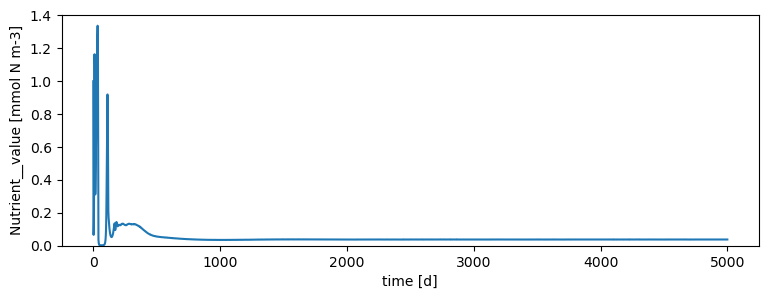

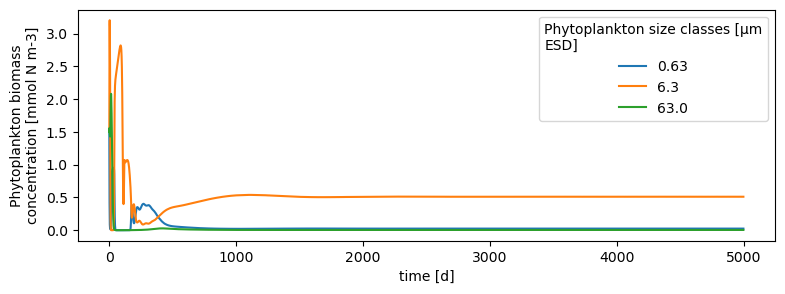

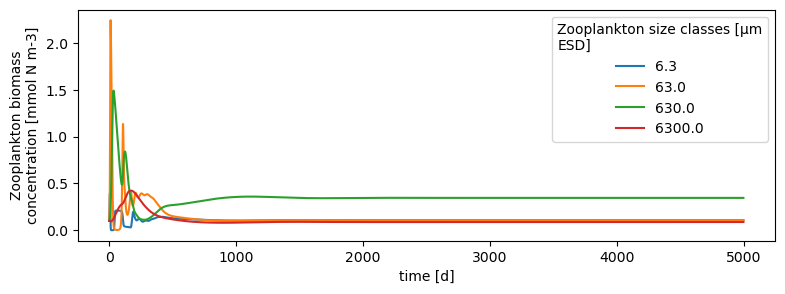

In [8]:
# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot.line(x='time', aspect=3, size=3)
# zooplankton:
model_out.Zooplankton__biomass.plot.line(x='time', aspect=3, size=3)

# THIS IS THE CANONICAL RUN, 
### let's move on to require only updating of model setup for the parameter runs

In [9]:
#
nutrient_input_cluster1 = 0.0053
#
nutrient_input_cluster2 = 0.00325

In [10]:
from tqdm import tqdm
from xsimlab.monitoring import ProgressBar

with ProgressBar():
    with Stocketal2008_mortsingleval:
        N0_parscan_modelout = model_setup.xsimlab.update_vars(
             input_vars={'N0': {'value':('batch', np.linspace(0.001,0.01, 25))}}
             ).xsimlab.run(batch_dim='batch')

/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/utils.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return xr_dataset.dims[batch_dim]
█████████████████████████████████████████████████████████████████████████████ 100% | Simulation finished in 00:01 
█████████████████████████████████████████████████████████████████████████████ 100% | Simulation finished in 00:01 
█████████████████████████████████████████████████████████████████████████████ 100% | Simulation finished in 00:01 
█████████████████

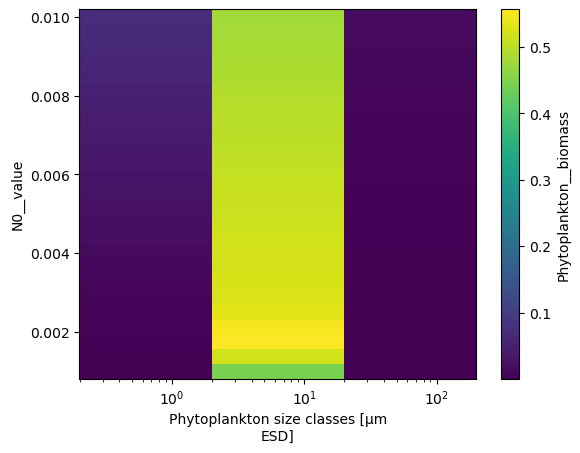

In [11]:
(N0_parscan_modelout.swap_dims({'batch':'N0__value'})
    .isel(time=slice(365*9,365*10))
    .Phytoplankton__biomass.mean(dim="time").plot(xscale='log', y='N0__value'))

In [12]:
with Stocketal2008_mortsingleval:
    Mz4_parscan_modelout = model_setup.xsimlab.update_vars(
         input_vars={'HigherOrderMortality': {'rate':('batch', np.linspace(0.001,0.01, 25))}}
         ).xsimlab.run(batch_dim='batch')

/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/utils.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return xr_dataset.dims[batch_dim]


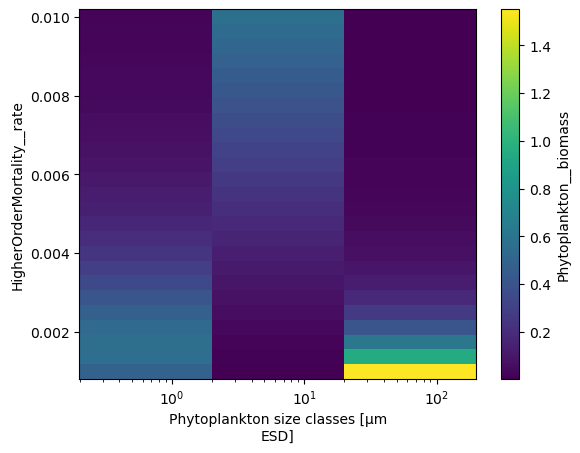

In [13]:
(Mz4_parscan_modelout.swap_dims({'batch':'HigherOrderMortality__rate'})
    .isel(time=slice(365*9,365*10))
    .Phytoplankton__biomass.mean(dim="time").plot(xscale='log', y='HigherOrderMortality__rate'))

# Alright, time for a break
- what else can I do?

3d plot makes it more obvious perhaps?
I could add a 4th information parameter in the color

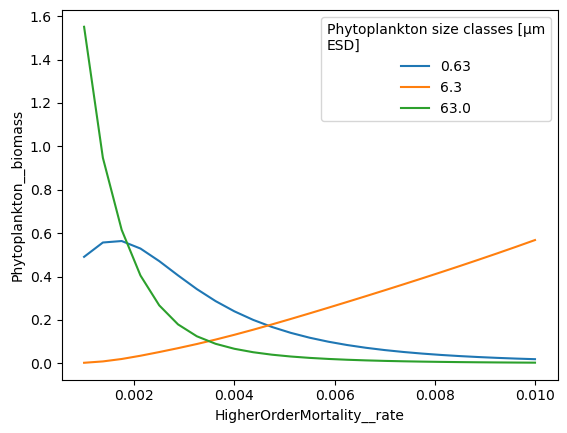

In [16]:
(Mz4_parscan_modelout.swap_dims({'batch':'HigherOrderMortality__rate'})
    .isel(time=slice(365*9,365*10))
    .Phytoplankton__biomass.mean(dim="time").plot.line(x='HigherOrderMortality__rate'))

In [76]:
from tqdm import tqdm
from xsimlab.monitoring import ProgressBar

with ProgressBar():
    with Stocketal2008_mortsingleval:
        N0_parscan_modelout = (
            model_setup.xsimlab.update_vars(
            # when using multiple dims use dim as variable names for this fix to work!
             input_vars={'N0': {'value':('N0__value', np.linspace(0.001,0.05, 5))}, 
                         'HigherOrderMortality': {'rate':('HigherOrderMortality__rate', np.linspace(0.001,0.01, 25))}})
            # create Multiindex for grid wise runs, create_index false for bug fix of new Xarray Version
            .stack(batch=['N0__value','HigherOrderMortality__rate'], create_index=False)
            # actually run model
            .xsimlab.run(batch_dim='batch')
            # bug fix of new Xarray Version
            .set_index(batch=["N0__value", "HigherOrderMortality__rate"]) 
            # unstack multiindex
            .unstack('batch')
        )

/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/utils.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return xr_dataset.dims[batch_dim]
███████████████████████████████████████████ 100% | Simulation finished in 00:02 
███████████████████████████████████████████ 100% | Simulation finished in 00:02 
███████████████████████████████████████████ 100% | Simulation finished in 00:02 
███████████████████████████████████████████ 100% | Simulation finished in 00:02 
███████████████████████████████████████████ 100% | Simulation finished in 00:01 
███████████████████████████████████████████ 100% | Simulation finished in 00:01 
███████████████████████████████████████████ 100% | Simulation finished in 00:01 
███████████████████████████████████████████ 100% | Simulation fin

ValueError: cannot reshape array of size 83468 into shape (7,4,5000)

In [77]:
N0_parscan_modelout

<xarray.Dataset> Size: 186MB
Dimensions:                                         (N0__value: 5,
                                                     HigherOrderMortality__rate: 15,
                                                     zoo: 4, time: 5000,
                                                     phyto: 3, full: 7, clock: 2)
Coordinates:
  * N0__value                                       (N0__value) float64 40B 0...
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 120B ...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/55)
    Core__solver_type                               <U9 36B 'solve_ivp'
    GGE__R                                          float64 8B 0.45
    GGE__alpha                                      float64 8B 0.7
    GGE__assimilated_consumer                       <U1 4B 'Z'
    GGE__assimilation_value                         (zoo, time, N0__value, HigherOrderMortality__rate) float64 12MB ...
    GGE__egested_detritus                           <U1 4B 'N'
    ...                                              ...
    Phytoplankton__phyto_index                      (phyto) float64 24B 0.63 ...
    Time__time_input                                (time) int64 40kB 0 ... 4999
    Zooplankton__biomass                            (zoo, time, N0__value, HigherOrderMortality__rate) float64 12MB ...
    Zooplankton__biomass_init                       (zoo) float64 32B 0.1 ......
    Zooplankton__biomass_label                      <U1 4B 'Z'
    Zooplankton__zoo_index                          (zoo) float64 32B 6.3 ......

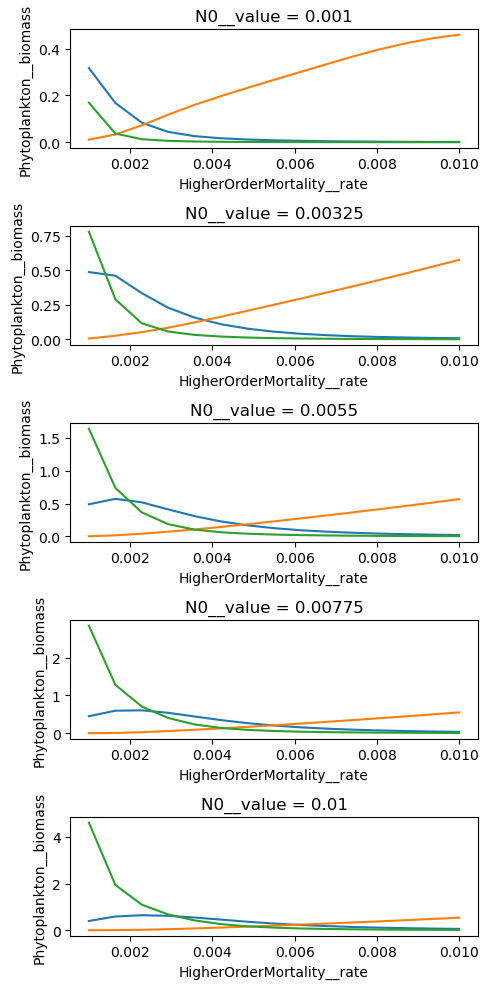

In [82]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

prrang=5
fig, ax = plt.subplots(prrang)

for val in np.arange(prrang):
    (N0_parscan_modelout
        .isel(time=slice(365*9,365*10), N0__value=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='HigherOrderMortality__rate', ax=ax[val], add_legend=False))

plt.tight_layout()

In [99]:
with Stocketal2008_mortsingleval:
    test= model_setup.xsimlab.update_vars(
             input_vars={'N0': {'value':('n_input', np.linspace(0.005,0.007, 2))}, 'HigherOrderMortality': {'rate':('mort_rate', np.linspace(0.009,0.011, 2))}}
             ).stack(batch=['mort_rate','n_input'])#.xsimlab.run(batch_dim='batch')

In [100]:
test

<xarray.Dataset> Size: 41kB
Dimensions:                           (clock: 2, phyto: 3, zoo: 4, full: 7,
                                       time: 5000, batch: 4)
Coordinates:
  * clock                             (clock) int64 16B 0 1
  * batch                             (batch) object 32B MultiIndex
  * mort_rate                         (batch) int64 32B 0 0 1 1
  * n_input                           (batch) int64 32B 0 1 0 1
Dimensions without coordinates: phyto, zoo, full, time
Data variables: (12/42)
    Nutrient__value_label             <U1 4B 'N'
    Nutrient__value_init              float64 8B 1.0
    Phytoplankton__biomass_label      <U1 4B 'P'
    Phytoplankton__biomass_init       (phyto) float64 24B 1.5 1.5 1.5
    Phytoplankton__phyto_index        (phyto) float64 24B 0.63 6.3 63.0
    Zooplankton__biomass_label        <U1 4B 'Z'
    ...                                ...
    HigherOrderMortality__recycling   (zoo) float64 32B 0.0 0.0 0.0 0.5
    N0__forcing_label                 <U2 8B 'N0'
    Core__solver_type                 <U9 36B 'solve_ivp'
    Time__time_input                  (time) int64 40kB 0 1 2 ... 4997 4998 4999
    N0__value                         (batch) float64 32B 0.005 0.007 ... 0.007
    HigherOrderMortality__rate        (batch) float64 32B 0.009 0.009 ... 0.011
Attributes:
    __xsimlab_output_vars__:  Nutrient__value,Phytoplankton__biomass,Zooplank...

In [ ]:
final_year = model_out.isel(time=slice(365*9,365*10))

.Phytoplankton__biomass.mean(dim="time").plot(xscale='log', y='batch')

# NOW, let's use the metrics I calculated for Cluster 1 & 2

In [12]:
np.linspace(0.0001,0.01, 25)

array([0.0001   , 0.0005125, 0.000925 , 0.0013375, 0.00175  , 0.0021625,
       0.002575 , 0.0029875, 0.0034   , 0.0038125, 0.004225 , 0.0046375,
       0.00505  , 0.0054625, 0.005875 , 0.0062875, 0.0067   , 0.0071125,
       0.007525 , 0.0079375, 0.00835  , 0.0087625, 0.009175 , 0.0095875,
       0.01     ])

In [13]:
model_setup = xso.setup(solver='solve_ivp', model=Stocketal2008,
            time=np.arange(0,365*10),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':1.0},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                 
                    'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
                
                    # Mortality
                    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_mortality_array, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':('batch', np.linspace(0.001,0.01, 2))},
            })

/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/xr_accessor.py:229: FutureWarning: variable 'clock' with name matching its dimension will not be automatically converted into an `IndexVariable` object in the future.
  xr_var = as_variable(data, name=dim)


In [14]:
model_setup = xso.setup(solver='solve_ivp', model=Stocketal2008_2,
            time=np.arange(0,365*10),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':1.0},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                 
                    'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
                
                    # Mortality
                    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':('batch', np.linspace(0.001,0.01, 25)), 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':nutrient_input},
            })

In [15]:
c1_setup = model_setup#.update({'N0__value':0.0053})

c1_setup

<xarray.Dataset> Size: 30kB
Dimensions:                           (clock: 2, phyto: 3, zoo: 4, full: 7,
                                       batch: 25, time: 3650)
Coordinates:
  * clock                             (clock) int64 16B 0 1
Dimensions without coordinates: phyto, zoo, full, batch, time
Data variables: (12/42)
    Nutrient__value_label             <U1 4B 'N'
    Nutrient__value_init              float64 8B 1.0
    Phytoplankton__biomass_label      <U1 4B 'P'
    Phytoplankton__biomass_init       (phyto) float64 24B 1.5 1.5 1.5
    Phytoplankton__phyto_index        (phyto) float64 24B 0.63 6.3 63.0
    Zooplankton__biomass_label        <U1 4B 'Z'
    ...                                ...
    HigherOrderMortality__exponent    (zoo) int64 32B 0 0 0 1
    HigherOrderMortality__recycling   (zoo) float64 32B 0.0 0.0 0.0 0.5
    N0__forcing_label                 <U2 8B 'N0'
    N0__value                         float64 8B 0.0053
    Core__solver_type                 <U9 36B 'solve_ivp'
    Time__time_input                  (time) int64 29kB 0 1 2 ... 3647 3648 3649
Attributes:
    __xsimlab_output_vars__:  Nutrient__value,Phytoplankton__biomass,Zooplank...

In [17]:
with Stocketal2008_2:
        c1_out = c1_setup.xsimlab.run(batch_dim='batch')

/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/utils.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return xr_dataset.dims[batch_dim]


In [116]:
model_out=c1_out.assign_coords({"batch": c1_out.N0__value.values}).swap_dims({'batch':'N0__value'})

In [117]:
final_year = model_out.isel(time=slice(365*9,365*10))

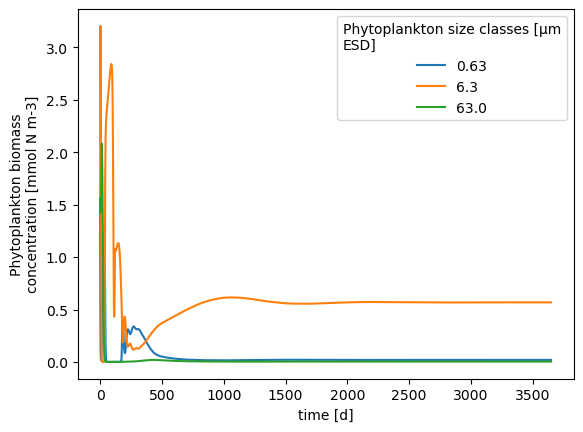

In [30]:
c1_out.Phytoplankton__biomass.isel(batch=24).plot.line(x="time")

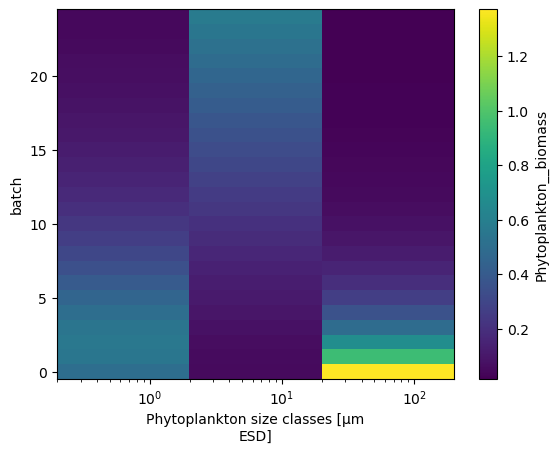

In [21]:
c1_out.Phytoplankton__biomass.mean(dim="time").plot(xscale='log', y='batch')

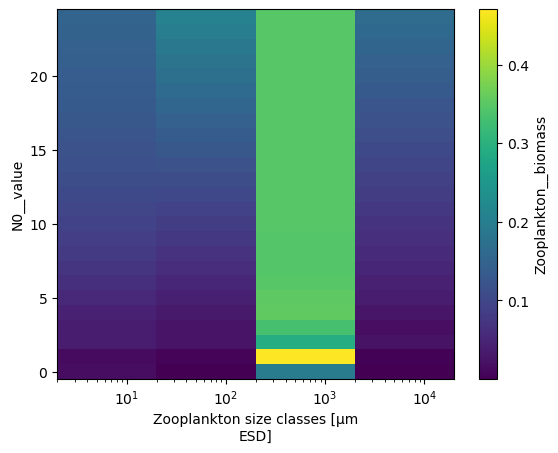

In [37]:

final_year.Zooplankton__biomass.swap_dims({'batch':'N0__value'}).mean(dim="time").plot(xscale='log', y='N0__value')

In [49]:
final_year.assign_coords({"batch": final_year.N0__value.values})

<xarray.Dataset> Size: 5MB
Dimensions:                                         (batch: 25, zoo: 4,
                                                     time: 365, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 3kB 3.285e...
  * zoo                                             (zoo) float64 32B 6.3 ......
  * batch                                           (batch) float64 200B 0.00...
Dimensions without coordinates: full
Data variables: (12/57)
    Core__solver_type                               <U9 36B 'solve_ivp'
    GGE__R                                          float64 8B 0.45
    GGE__alpha                                      float64 8B 0.7
    GGE__assimilated_consumer                       <U1 4B 'Z'
    GGE__assimilation_value                         (batch, zoo, time) float64 292kB ...
    GGE__egested_detritus                           <U1 4B 'N'
    ...                                              ...
    Phytoplankton__phyto_index                      (phyto) float64 24B 0.63 ...
    Time__time_input                                (time) int64 3kB 3285 ......
    Zooplankton__biomass                            (batch, zoo, time) float64 292kB ...
    Zooplankton__biomass_init                       (zoo) float64 32B 0.1 ......
    Zooplankton__biomass_label                      <U1 4B 'Z'
    Zooplankton__zoo_index                          (zoo) float64 32B 6.3 ......

In [40]:
final_year.Zooplankton__biomass.mean(dim="time").plot(xscale='log', y='N0__value')

ValueError: y must be one of None, 'batch', 'zoo'. Received 'N0__value' instead.